In [1]:
# ============================================================
# 04_evaluate.ipynb
# Model Evaluation
# Breast Tumor Classification Project
# ============================================================

In [2]:
# ============================================================
# 1. Import Libraries
# ============================================================

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Add project root to Python path
sys.path.append(str(Path().resolve().parent))

In [3]:
# ============================================================
# 2. Import Custom Modules
# ============================================================

from src.config import (
    PROCESSED_DATA_FILE,
    MODEL_FILE
)

from src.split import stratified_split

from src.train import generate_predictions

from src.evaluate import (
    calculate_metrics,
    get_confusion_matrix,
    generate_classification_report
)

from src.thresholding import apply_threshold

In [4]:
# ============================================================
# 3. Load Processed Dataset
# ============================================================

df = pd.read_csv(
    PROCESSED_DATA_FILE
)

df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [5]:
# ============================================================
# 4. Split Features and Target
# ============================================================

X = df.drop(columns=['Diagnosis'])

y = df['Diagnosis']

In [6]:
# ============================================================
# 5. Perform Stratified Split
# ============================================================

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = stratified_split(X, y)

In [7]:
# ============================================================
# 6. Load Trained Model
# ============================================================

model = joblib.load(MODEL_FILE)

print("Model loaded successfully.")

Model loaded successfully.


In [8]:
# ============================================================
# 7. Generate Predictions
# ============================================================

test_predictions, test_probabilities = generate_predictions(
    model,
    X_test
)


In [9]:
# ============================================================
# 8. Calculate Metrics
# ============================================================

metrics = calculate_metrics(
    y_test,
    test_predictions,
    test_probabilities
)

print("Evaluation Metrics:\n")

for metric, value in metrics.items():

    print(f"{metric}: {value:.4f}")

Evaluation Metrics:

accuracy: 0.9884
precision: 1.0000
recall: 0.9688
f1_score: 0.9841
roc_auc: 1.0000


In [10]:
# ============================================================
# 9. Classification Report
# ============================================================

report = generate_classification_report(
    y_test,
    test_predictions
)

print(report)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       1.00      0.97      0.98        32

    accuracy                           0.99        86
   macro avg       0.99      0.98      0.99        86
weighted avg       0.99      0.99      0.99        86



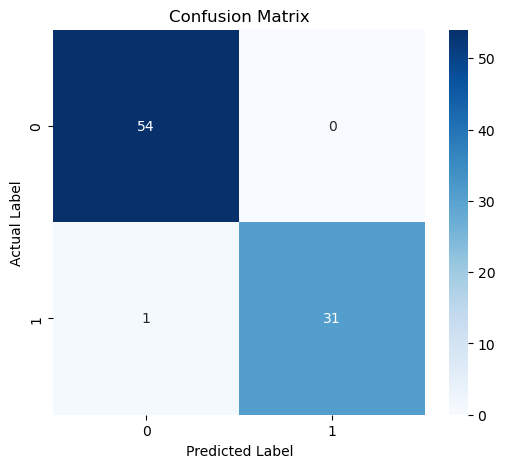

In [11]:
# ============================================================
# 10. Confusion Matrix
# ============================================================

cm = get_confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

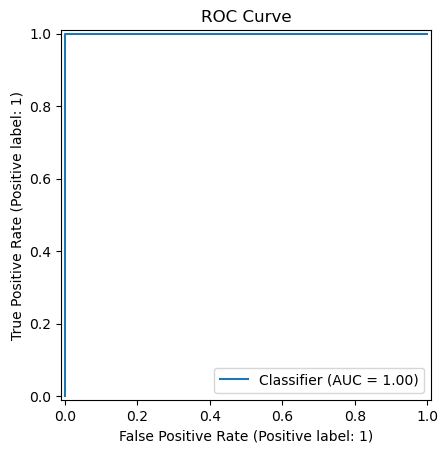

In [12]:
# ============================================================
# 11. ROC Curve
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities
)

plt.title("ROC Curve")

plt.show()

In [13]:
# ============================================================
# 12. Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

feature_importance.head(10)

,Feature,Importance
22,perimeter_worst,0.142622
23,area_worst,0.127106
7,concave_points_mean,0.120441
27,concave_points_worst,0.093218
20,radius_worst,0.070894
6,concavity_mean,0.054502
0,radius_mean,0.053252
2,perimeter_mean,0.051770
3,area_mean,0.041242
26,concavity_worst,0.039223


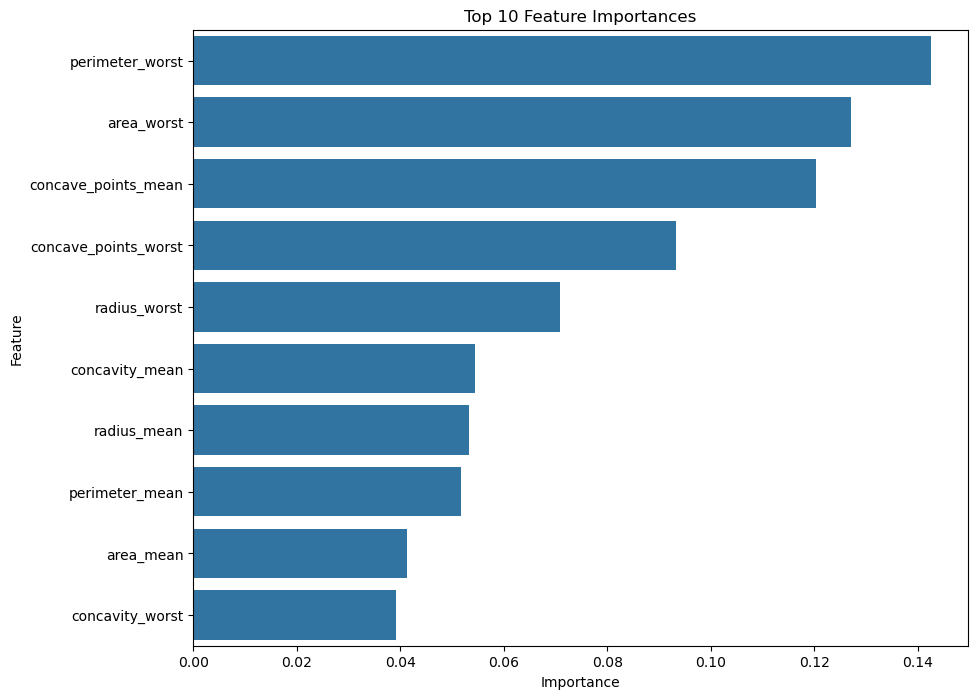

In [14]:
# ============================================================
# 13. Plot Feature Importance
# ============================================================

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")

plt.show()

In [15]:
# ============================================================
# 14. Threshold Analysis
# ============================================================

custom_threshold = 0.40

threshold_predictions = apply_threshold(
    test_probabilities,
    threshold=custom_threshold
)

threshold_metrics = calculate_metrics(
    y_test,
    threshold_predictions,
    test_probabilities
)

print(f"\nMetrics at Threshold {custom_threshold}:\n")

for metric, value in threshold_metrics.items():

    print(f"{metric}: {value:.4f}")


Metrics at Threshold 0.4:

accuracy: 0.9884
precision: 1.0000
recall: 0.9688
f1_score: 0.9841
roc_auc: 1.0000


# Evaluation Summary

## Evaluation Workflow

1. The processed dataset and trained Random Forest model were loaded successfully.

2. Predictions and malignancy probabilities were generated for the test dataset.

3. The following evaluation metrics were calculated:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC

4. A confusion matrix was generated to analyze:
   - False Positives
   - False Negatives

5. A ROC Curve was plotted to evaluate threshold-independent model performance.

6. Feature importance analysis identified the most influential predictors used by the Random Forest model.

7. Threshold analysis was performed to study how prediction thresholds affect Recall and Precision.

## Why Evaluation Is Important

- Accuracy alone is insufficient for medical classification tasks.
- Recall is critical because missing malignant tumors is costly.
- ROC-AUC measures overall ranking capability.
- Threshold tuning helps balance false positives and false negatives.
- Feature importance improves interpretability and trust in the model.